This notebook code allow us to detect and classify palm trees.

Dataset de test

In [1]:
import os
import cv2
import pandas as pd
from ultralytics import YOLO
from tqdm import tqdm

yolo_env_classifier = r"F:\Universidad\Curso 2024-25\Segundo Semestre\TFG\Desarrollo\dataset\classification_per_type\environment_classification_dataset\yolov11m_cls\fixed_ot\environment_classification_model_fixed_ot\weights\best.pt"
yolo_palm_classifier = r"F:\Universidad\Curso 2024-25\Segundo Semestre\TFG\Desarrollo\dataset\classification_per_type\palm_type_classification_dataset\yolov11m_cls\palm_type_classification_model_45px\weights\best.pt"
test_dir = r"F:\Universidad\Curso 2024-25\Segundo Semestre\TFG\Desarrollo\dataset\fixed_normalization\Val\images"
output_csv = "clasificacion_resultados_validation.csv"

# Cargar modelos
detection_dir = r"C:\Users\hugoh\OneDrive\Documentos\ArcGIS\Projects\TFG_palmeras\runs\detect\fixed_normalization\bbox_45\train_yolov11m\weights\best.pt"
detector = YOLO(detection_dir)
classifier_pal = YOLO(yolo_palm_classifier)
classifier_env = YOLO(yolo_env_classifier)

# Inicializar resultados
rows = []

# Procesar imágenes
for filename in tqdm(os.listdir(test_dir), desc="Procesando imágenes"):
    if not filename.lower().endswith(('.png')):
        continue

    image_path = os.path.join(test_dir, filename)
    image = cv2.imread(image_path)
    if image is None:
        print(f"No se pudo leer: {filename}")
        continue

    img_h, img_w = image.shape[:2]

    # Detección de palmeras
    results = detector.predict(
        source=image,
        conf=0.184,
        device=0,
        imgsz=960)[0]

    for box in results.boxes:
        x1, y1, x2, y2 = map(int, box.xyxy[0])
        print(x1, y1, x2, y2)
        conf = float(box.conf[0])

        # Clasificación tipo palmera
        bbox_crop = image[y1:y2, x1:x2]
        if bbox_crop.size == 0:
            continue
        pal_result = classifier_pal(bbox_crop)[0]
        pal_class = int(pal_result.probs.top1)
        pal_conf = float(pal_result.probs.top1conf)

        #  Clasificación tipo ambiente
        xc = int((x1 + x2) / 2)
        yc = int((y1 + y2) / 2)
        roi_size = 256
        env_x1 = max(0, xc - roi_size // 2)
        env_y1 = max(0, yc - roi_size // 2)
        env_x2 = min(img_w, xc + roi_size // 2)
        env_y2 = min(img_h, yc + roi_size // 2)
        env_crop = image[env_y1:env_y2, env_x1:env_x2]
        if env_crop.size == 0:
            continue
        env_result = classifier_env(env_crop)[0]
        env_class = int(env_result.probs.top1)
        env_conf = float(env_result.probs.top1conf)

        # Guardar fila
        rows.append({
            "image": filename,
            "bbox_x1": x1,
            "bbox_y1": y1,
            "bbox_x2": x2,
            "bbox_y2": y2,
            "det_confidence": conf,
            "palm_class": pal_class,
            "palm_confidence": pal_conf,
            "environment_class": env_class,
            "environment_confidence": env_conf
        })

# Guardar CSV
df = pd.DataFrame(rows)
df.to_csv(output_csv, index=False)
print(f"Clasificación finalizada. Resultados guardados en: {output_csv}")

c:\Users\hugoh\anaconda3\envs\TFG_yolov11\Lib\site-packages\requests\__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(
Procesando imágenes:   0%|          | 0/83 [00:00<?, ?it/s]


0: 704x960 35 items, 59.5ms
Speed: 6.6ms preprocess, 59.5ms inference, 124.7ms postprocess per image at shape (1, 3, 704, 960)
181 540 230 588

0: 64x64 pc 0.77, pme 0.07, hme 0.06, bdc 0.06, da 0.02, 5.4ms
Speed: 2.7ms preprocess, 5.4ms inference, 0.0ms postprocess per image at shape (1, 3, 64, 64)

0: 256x256 ru 0.46, ot 0.23, uj 0.15, na 0.08, ud 0.05, 4.4ms
Speed: 1.9ms preprocess, 4.4ms inference, 0.0ms postprocess per image at shape (1, 3, 256, 256)
169 670 220 721

0: 64x64 pc 0.35, bdc 0.26, hme 0.21, pme 0.09, tdi 0.07, 5.1ms
Speed: 1.3ms preprocess, 5.1ms inference, 0.0ms postprocess per image at shape (1, 3, 64, 64)

0: 256x256 uj 0.66, ot 0.20, vi 0.06, ru 0.03, ud 0.02, 5.7ms
Speed: 2.6ms preprocess, 5.7ms inference, 0.0ms postprocess per image at shape (1, 3, 256, 256)
233 477 286 531

0: 64x64 pc 0.64, pme 0.11, hme 0.09, bdc 0.07, da 0.06, 4.6ms
Speed: 1.1ms preprocess, 4.6ms inference, 0.0ms postprocess per image at shape (1, 3, 64, 64)

0: 256x256 uj 0.32, ru 0.32, n

Procesando imágenes:   1%|          | 1/83 [00:01<02:43,  1.99s/it]


0: 704x960 26 items, 25.6ms
Speed: 4.9ms preprocess, 25.6ms inference, 1.7ms postprocess per image at shape (1, 3, 704, 960)
378 38 423 82

0: 64x64 pme 0.36, da 0.34, bdc 0.11, tdi 0.08, hme 0.06, 4.6ms
Speed: 0.8ms preprocess, 4.6ms inference, 0.0ms postprocess per image at shape (1, 3, 64, 64)

0: 256x256 ud 0.91, ot 0.08, uj 0.01, rd 0.00, vi 0.00, 5.8ms
Speed: 2.5ms preprocess, 5.8ms inference, 0.1ms postprocess per image at shape (1, 3, 256, 256)
335 249 379 292

0: 64x64 pme 0.73, da 0.13, tdi 0.04, hme 0.04, pc 0.03, 9.2ms
Speed: 1.7ms preprocess, 9.2ms inference, 0.0ms postprocess per image at shape (1, 3, 64, 64)

0: 256x256 uj 0.50, ud 0.45, ot 0.05, vi 0.00, rd 0.00, 4.9ms
Speed: 1.8ms preprocess, 4.9ms inference, 0.0ms postprocess per image at shape (1, 3, 256, 256)
504 322 550 368

0: 64x64 pc 0.35, tdi 0.31, pme 0.24, hme 0.05, da 0.04, 5.7ms
Speed: 1.0ms preprocess, 5.7ms inference, 0.0ms postprocess per image at shape (1, 3, 64, 64)

0: 256x256 ud 0.71, uj 0.23, ot 0.

Procesando imágenes:   2%|▏         | 2/83 [00:02<01:35,  1.18s/it]

...


0: 704x960 300 items, 29.9ms
Speed: 4.3ms preprocess, 29.9ms inference, 2.6ms postprocess per image at shape (1, 3, 704, 960)
453 319 499 366

0: 64x64 pc 0.80, tdi 0.07, pme 0.06, da 0.04, bdc 0.03, 10.0ms
Speed: 2.1ms preprocess, 10.0ms inference, 0.0ms postprocess per image at shape (1, 3, 64, 64)

0: 256x256 ud 0.66, uj 0.28, rd 0.05, ru 0.01, ot 0.00, 5.9ms
Speed: 1.8ms preprocess, 5.9ms inference, 0.0ms postprocess per image at shape (1, 3, 256, 256)
237 203 284 249

0: 64x64 pc 0.52, da 0.18, hme 0.11, bdc 0.08, pme 0.06, 6.0ms
Speed: 2.1ms preprocess, 6.0ms inference, 0.0ms postprocess per image at shape (1, 3, 64, 64)

0: 256x256 ud 0.62, rd 0.36, ru 0.02, uj 0.01, ot 0.00, 5.4ms
Speed: 1.7ms preprocess, 5.4ms inference, 0.0ms postprocess per image at shape (1, 3, 256, 256)
110 372 155 417

0: 64x64 pc 0.34, da 0.24, pme 0.13, hme 0.11, bdc 0.10, 5.1ms
Speed: 1.0ms preprocess, 5.1ms inference, 0.0ms postprocess per image at shape (1, 3, 64, 64)

0: 256x256 rd 0.70, ud 0.25, u

Procesando imágenes:  99%|█████████▉| 82/83 [02:06<00:04,  4.64s/it]


0: 704x960 300 items, 30.3ms
Speed: 4.3ms preprocess, 30.3ms inference, 2.3ms postprocess per image at shape (1, 3, 704, 960)
225 387 272 434

0: 64x64 pc 0.44, pme 0.20, da 0.15, bdc 0.08, hme 0.07, 4.2ms
Speed: 1.2ms preprocess, 4.2ms inference, 0.0ms postprocess per image at shape (1, 3, 64, 64)

0: 256x256 ud 0.89, rd 0.08, uj 0.03, ru 0.00, ot 0.00, 4.7ms
Speed: 1.5ms preprocess, 4.7ms inference, 0.0ms postprocess per image at shape (1, 3, 256, 256)
409 151 453 196

0: 64x64 pc 0.55, bdc 0.13, hme 0.13, da 0.09, tdi 0.05, 4.3ms
Speed: 1.1ms preprocess, 4.3ms inference, 0.0ms postprocess per image at shape (1, 3, 64, 64)

0: 256x256 ud 0.55, uj 0.42, vi 0.02, rd 0.00, ru 0.00, 5.5ms
Speed: 1.6ms preprocess, 5.5ms inference, 0.0ms postprocess per image at shape (1, 3, 256, 256)
452 149 498 196

0: 64x64 pc 0.81, bdc 0.11, hme 0.03, pme 0.03, tdi 0.02, 6.3ms
Speed: 1.0ms preprocess, 6.3ms inference, 0.0ms postprocess per image at shape (1, 3, 64, 64)

0: 256x256 uj 0.74, ud 0.25, vi

Procesando imágenes: 100%|██████████| 83/83 [02:11<00:00,  1.59s/it]

Clasificación finalizada. Resultados guardados en: clasificacion_resultados_validation.csv


Comprobamos Verdaderos o Falsos Positivos

In [2]:
import os
import json
import pandas as pd

json_dir = r"F:\Universidad\Curso 2024-25\Segundo Semestre\TFG\Desarrollo\dataset\fixed_normalization\Val\json_annotations"
output_csv = "ground_truth_validation.csv"

rows = []

for file in os.listdir(json_dir):
    if not file.endswith(".json"):
        continue

    with open(os.path.join(json_dir, file), "r", encoding="utf-8") as f:
        data = json.load(f)

    image_name = data["image"]
    palm_id = data.get("id", "unknown")

    for palm in data.get("palms", []):
        bbox = palm["bbox_pixel"]
        xc = bbox["x_center"]
        yc = bbox["y_center"]
        w = bbox["width"]
        h = bbox["height"]
        x1 = int(xc - w / 2)
        y1 = int(yc - h / 2)
        x2 = int(xc + w / 2)
        y2 = int(yc + h / 2)

        environment = palm["attributes"].get("Tip_amb")
        palm_type = palm["attributes"].get("Hibrid")

        # Solo incluimos palmas con clase conocida
        if environment == "?" or palm_type == "?":
            continue

        # Mapea clases a IDs (asegúrate que coincide con lo que usaste para entrenar)
        environment_class = {"na": 0, "ot": 1, "rd" : 2, "ru": 3, "ud": 4, "uj": 5, "vi": 6}[environment.lower()]
        palm_class = {"bdc": 0, "da": 1, "hme": 2, "pc": 3, "pme": 4, "tdi": 5}[palm_type.lower()]
        rows.append({
            "image": image_name,
            "bbox_x1": x1,
            "bbox_y1": y1,
            "bbox_x2": x2,
            "bbox_y2": y2,
            "palm_class": palm_class,
            "environment_class": environment_class
        })

df = pd.DataFrame(rows)
df.to_csv(output_csv, index=False)
print(f"ground_truth.csv guardado en: {output_csv}")

ground_truth.csv guardado en: ground_truth_validation.csv


In [3]:
import pandas as pd

gt = pd.read_csv("ground_truth_validation.csv")
pred = pd.read_csv("clasificacion_resultados_validation.csv")

print("Ground truth:", len(gt))
print("Clasificaciones realizadas:", len(pred))

print("\nImágenes en común:", len(set(gt["image"]) & set(pred["image"])))

Ground truth: 8834
Clasificaciones realizadas: 6991

Imágenes en común: 82


Ahora, comparamos resultados de las predicciones con las detecciones y etiquetas reales

Resultados:
True Positives (TP): 3428
False Positives (FP): 3563
False Negatives (FN): 5406
Precisión detección: 0.49
Recall detección: 0.39
Accuracy clasificación ambiente: 2088/3428 = 0.61
Accuracy clasificación tipo palmera: 1831/3428 = 0.53


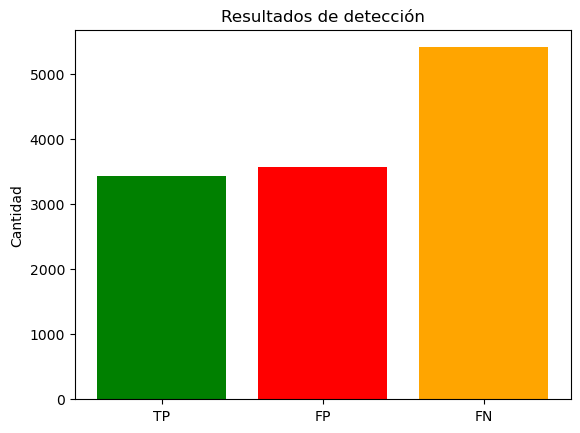

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# === Función para calcular IoU ===
def calculate_iou(boxA, boxB):
    xA = max(boxA[0], boxB[0])
    yA = max(boxA[1], boxB[1])
    xB = min(boxA[2], boxB[2])
    yB = min(boxA[3], boxB[3])
    interWidth = max(0, xB - xA + 1)
    interHeight = max(0, yB - yA + 1)
    interArea = interWidth * interHeight
    boxAArea = (boxA[2] - boxA[0] + 1) * (boxA[3] - boxA[1] + 1)
    boxBArea = (boxB[2] - boxB[0] + 1) * (boxB[3] - boxB[1] + 1)
    iou = interArea / float(boxAArea + boxBArea - interArea + 1e-6)
    return iou

# Cargar CSVs
gt_df = pd.read_csv("ground_truth_validation.csv")
pred_df = pd.read_csv("clasificacion_resultados_validation.csv")

tp, fp, fn = 0, 0, 0
correct_env_cls, correct_palm_cls = 0, 0
total_env_cls, total_palm_cls = 0, 0

matched_gt = set()

# === Comparación detección y clasificación ===
for _, pred in pred_df.iterrows():
    found_match = False
    pred_box = [pred["bbox_x1"], pred["bbox_y1"], pred["bbox_x2"], pred["bbox_y2"]]
    image = pred["image"]

    gt_image_df = gt_df[gt_df["image"] == image]

    for gt_idx, gt in gt_image_df.iterrows():
        gt_box = [gt["bbox_x1"], gt["bbox_y1"], gt["bbox_x2"], gt["bbox_y2"]]
        iou = calculate_iou(pred_box, gt_box)

        if iou >= 0.4 and gt_idx not in matched_gt:
            found_match = True
            matched_gt.add(gt_idx)
            tp += 1

            total_env_cls += 1
            total_palm_cls += 1

            if pred["environment_class"] == gt["environment_class"]:
                correct_env_cls += 1
            if pred["palm_class"] == gt["palm_class"]:
                correct_palm_cls += 1
            break

    if not found_match:
        fp += 1

fn = len(gt_df) - len(matched_gt)

# Mostrar métricas
print(f"Resultados:")
print(f"True Positives (TP): {tp}")
print(f"False Positives (FP): {fp}")
print(f"False Negatives (FN): {fn}")
print(f"Precisión detección: {tp / (tp + fp):.2f}")
print(f"Recall detección: {tp / (tp + fn):.2f}")
print(f"Accuracy clasificación ambiente: {correct_env_cls}/{total_env_cls} = {correct_env_cls / total_env_cls:.2f}")
print(f"Accuracy clasificación tipo palmera: {correct_palm_cls}/{total_palm_cls} = {correct_palm_cls / total_palm_cls:.2f}")

# Gráfica de barras
plt.bar(["TP", "FP", "FN"], [tp, fp, fn], color=["green", "red", "orange"])
plt.title("Resultados de detección")
plt.ylabel("Cantidad")
plt.show()

Resultados (sin filtrar duplicados por ground truth):
True Positives (TP): 3861
False Positives (FP): 3130
False Negatives (FN): 5676
Precisión detección: 0.55
Recall detección: 0.40
Accuracy ambiente: 2335/3861 = 0.60
Accuracy tipo palmera: 2189/3861 = 0.57


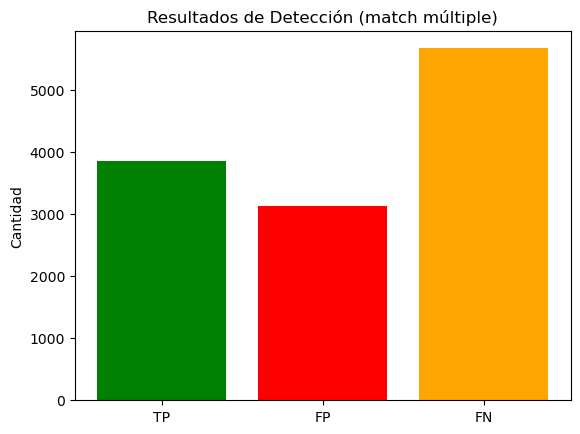

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

def calculate_iou(boxA, boxB):
    xA = max(boxA[0], boxB[0])
    yA = max(boxA[1], boxB[1])
    xB = min(boxA[2], boxB[2])
    yB = min(boxA[3], boxB[3])
    interArea = max(0, xB - xA + 1) * max(0, yB - yA + 1)
    boxAArea = (boxA[2] - boxA[0] + 1) * (boxA[3] - boxA[1] + 1)
    boxBArea = (boxB[2] - boxB[0] + 1) * (boxB[3] - boxB[1] + 1)
    iou = interArea / float(boxAArea + boxBArea - interArea + 1e-6)
    return iou

# Cargar CSVs
gt_df = pd.read_csv("ground_truth_validation.csv")
pred_df = pd.read_csv("clasificacion_resultados_validation.csv")

tp, fp, fn = 0, 0, 0
correct_env_cls, correct_palm_cls = 0, 0
total_env_cls, total_palm_cls = 0, 0

# === Comparación sin restringir matches
for _, pred in pred_df.iterrows():
    pred_box = [pred["bbox_x1"], pred["bbox_y1"], pred["bbox_x2"], pred["bbox_y2"]]
    image = pred["image"]
    gt_image_df = gt_df[gt_df["image"] == image]

    matched = False

    for _, gt in gt_image_df.iterrows():
        gt_box = [gt["bbox_x1"], gt["bbox_y1"], gt["bbox_x2"], gt["bbox_y2"]]
        iou = calculate_iou(pred_box, gt_box)

        if iou >= 0.5:
            matched = True
            tp += 1
            total_env_cls += 1
            total_palm_cls += 1
            if pred["environment_class"] == gt["environment_class"]:
                correct_env_cls += 1
            if pred["palm_class"] == gt["palm_class"]:
                correct_palm_cls += 1
            break  # Si quieres permitir múltiples matches por GT, quita este `break`

    if not matched:
        fp += 1

# Cada GT que no tiene ninguna detección encima, cuenta como FN
# Para esto necesitamos ver qué GTs no tienen ninguna detección asociada
# Repetimos proceso inverso para contarlos

detected_gt_indices = set()
for _, gt in gt_df.iterrows():
    gt_box = [gt["bbox_x1"], gt["bbox_y1"], gt["bbox_x2"], gt["bbox_y2"]]
    image = gt["image"]
    pred_image_df = pred_df[pred_df["image"] == image]

    matched = False
    for _, pred in pred_image_df.iterrows():
        pred_box = [pred["bbox_x1"], pred["bbox_y1"], pred["bbox_x2"], pred["bbox_y2"]]
        if calculate_iou(gt_box, pred_box) >= 0.5:
            matched = True
            break

    if not matched:
        fn += 1

# Mostrar métricas
print("Resultados (sin filtrar duplicados por ground truth):")
print(f"True Positives (TP): {tp}")
print(f"False Positives (FP): {fp}")
print(f"False Negatives (FN): {fn}")
print(f"Precisión detección: {tp / (tp + fp):.2f}")
print(f"Recall detección: {tp / (tp + fn):.2f}")
print(f"Accuracy ambiente: {correct_env_cls}/{total_env_cls} = {correct_env_cls / total_env_cls:.2f}")
print(f"Accuracy tipo palmera: {correct_palm_cls}/{total_palm_cls} = {correct_palm_cls / total_palm_cls:.2f}")

# Visualización
plt.bar(["TP", "FP", "FN"], [tp, fp, fn], color=["green", "red", "orange"])
plt.title("Resultados de Detección (match múltiple)")
plt.ylabel("Cantidad")
plt.show()
